## Exploratory Data Analysis on the Cleaned Glassdoor Dataset

Cleaned Dataset : [salary_data_cleaned.csv](../data/cleaned/salary_data_cleaned.csv)

In [34]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Should give this notebook's directory to access to parent directory by adding it to the python module's search list

For those who are seeing this and don't know what module means (Modules -> .py and .ipynb, Packages -> Directory)

In [35]:
sys.path.append("..")

#### Load the cleaned dataset

In [36]:
df = pd.read_csv("../data/cleaned/salary_data_cleaned.csv")
df.head()

,job_title,salary_estimate,job_description,rating,company_name,location,headquarters,size,founded,type_of_ownership,...,python_yn,r_yn,power bi_yn,sql_yn,excel_yn,spark_yn,title_simplified,seniority,desc_len,competitor_count
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,True,False,True,False,True,False,data scientist,na,2536,0
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,True,True,False,False,False,False,data scientist,na,4783,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,True,True,False,True,True,True,data scientist,na,3461,0
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,True,False,False,False,False,False,data scientist,na,3883,3
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,True,True,False,True,False,False,data scientist,na,2728,3


In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,466.0,3.661803,0.776759,-1.0,3.4,3.7,4.1,5.0
founded,466.0,1836.375536,502.044442,-1.0,1939.0,1991.5,2007.0,2019.0
hourly,466.0,0.021459,0.145065,0.0,0.0,0.0,0.0,1.0
employer_provided_salary,466.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
min_salary,466.0,74.278970,30.560067,10.0,53.0,71.0,90.0,202.0
max_salary,466.0,127.607296,45.203700,16.0,98.0,124.0,150.0,306.0
avg_salary,466.0,111.418455,45.840101,15.0,79.5,106.5,135.0,303.0
same_state,466.0,0.538627,0.499041,0.0,0.0,1.0,1.0,1.0
company_age,466.0,50.362661,52.823865,-1.0,16.0,30.0,61.0,282.0
min_emp_count,461.0,2563.624729,3682.279718,1.0,201.0,501.0,5001.0,10000.0


##### Quick Data Exploring on columns

##### Rating per annum

<Axes: >

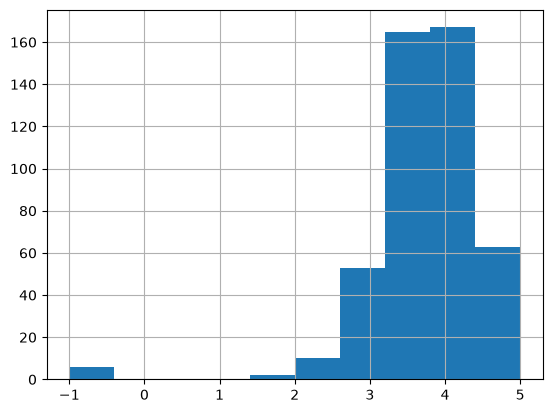

In [38]:
df.rating.hist()

##### Salary per annum

<Axes: >

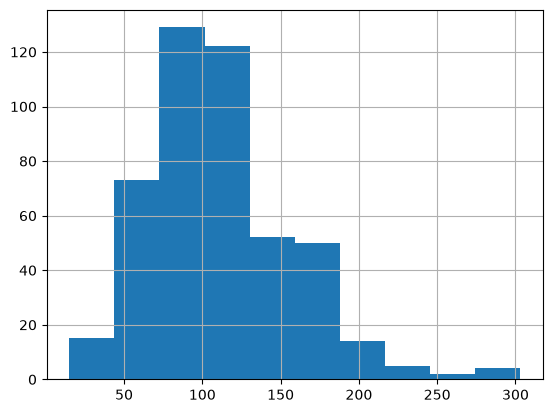

In [39]:
df.avg_salary.hist()

##### Checking the range and outliers

If you dont understand the line and the triangle inside the box, here's what it means
1. Line: 
-   This shows you the median. (Median means the exact middle value when sorted)
2. Green Triangle: 
-   This shows you the mean (Mathematical average value, Sum of all numbers / Count of all the numbers), average is another word for this, but we use mean in data science

<Axes: >

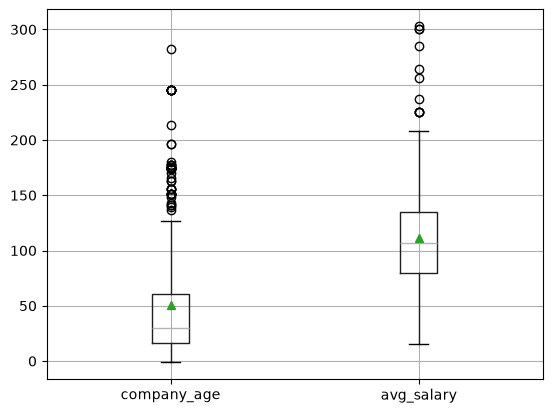

In [40]:
df.boxplot(column= ['company_age', 'avg_salary'], showmeans=True)

<Axes: >

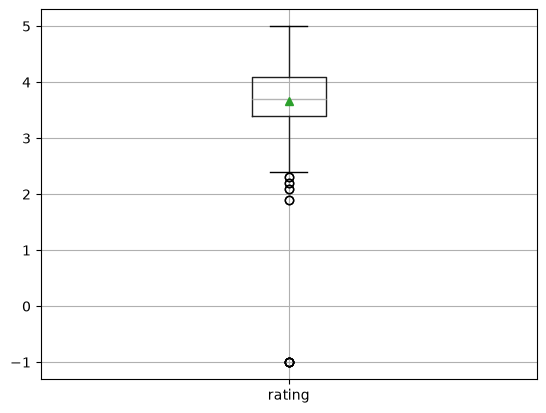

In [41]:
df.boxplot(column=['rating'], showmeans=True)

#### Correlation of specific fields

This can show how each fields can be correlated

According to the graph we can identify these things.

1. company_age is highly correlated with avg_emp_count
-  This means that when the company's age is increased/decreased the employee count (avg) can result the same
2. company_age, rating is not correlated with avg_salary
-  This means eventhough the company is old/new or rating is high/low doesn't mean high/low avg salary. (Ex. Increase of company age or rating doesn't mean high salary)

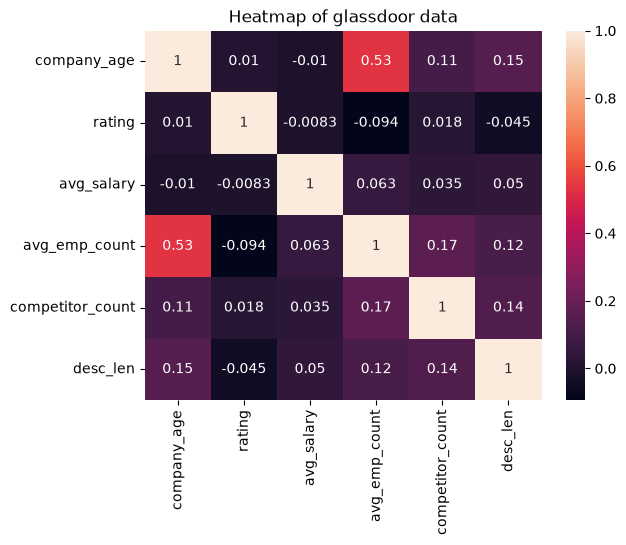

In [42]:
corr = df_cat[['company_age', 'rating', 'avg_salary', 'avg_emp_count', 'competitor_count', 'desc_len']].corr(numeric_only=True) # To check the correlation between numeric only

sns.heatmap(corr, annot=True)
plt.title("Heatmap of glassdoor data")
plt.show()

#### Categorical Fields

We take out categorical fields so we can create graphs based on that and excluding other fields

In [43]:
df_cat = df[[
    'rating', 'location', 'headquarters', 'size', 'type_of_ownership', 'industry', 'sector', 'revenue', 'min_salary', 'max_salary', 'avg_salary', 'same_state', 'company_age',
    'min_emp_count', 'max_emp_count', 'avg_emp_count', 'python_yn', 'r_yn', 'power bi_yn', 'sql_yn', 'excel_yn', 'spark_yn', 'title_simplified','seniority', 'desc_len', 'competitor_count'
]]